In [39]:
from pyexpat import features
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle
from tensorflow.keras.applications import ResNet152


In [40]:
model=Sequential()
model.add(Dense(512,activation='relu',input_dim=51200))
model.add(Dropout(0.3))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [41]:
with open('features.h5', 'rb') as f:
    features=pickle.load(f)
with open('labels.h5', 'rb') as f:
    labels=pickle.load(f)


In [42]:
with open('features_test.h5', 'rb') as f:
    features_test=pickle.load(f)
with open('labels_test.h5', 'rb') as f:
    labels_test=pickle.load(f)

In [43]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,379,265 (100.63 MB)

 Trainable params: 26,379,265 (100.63 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history=model.fit(features,labels,epochs=30,batch_size=50,validation_data=(features_test,labels_test))

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5020 - loss: 1.2011 - val_accuracy: 0.5414 - val_loss: 0.6859
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5055 - loss: 0.7411 - val_accuracy: 0.5479 - val_loss: 0.6873
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5470 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.7079
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5450 - loss: 0.6823 - val_accuracy: 0.6093 - val_loss: 0.6658
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.5570 - loss: 0.6784 - val_accuracy: 0.5157 - val_loss: 0.6916
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5290 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.5010 - loss: 0.6931 - val_accuracy: 0.5014 - val_loss: 0.6932
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5035 - loss: 0.6938 - val_accuracy: 0.5164 - 

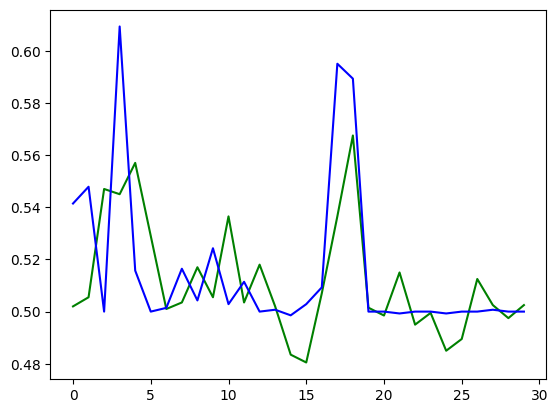

In [46]:
import matplotlib.pyplot as plt
epach=range(30)
plt.plot(epach,history.history['accuracy'] ,color='green')
plt.plot(epach,history.history['val_accuracy'] ,color='blue')